<a href="https://colab.research.google.com/github/MNTech955/100-days-of-machine-learning/blob/main/end_to_end_toye_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import numpy as np
import pandas as pd



In [49]:
df = pd.read_csv('/content/placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [50]:
df.shape


(100, 4)

In [51]:
#now we will perform this step to train machine learning model
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [53]:
df = df.iloc[:, 1:]
df.head()


,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


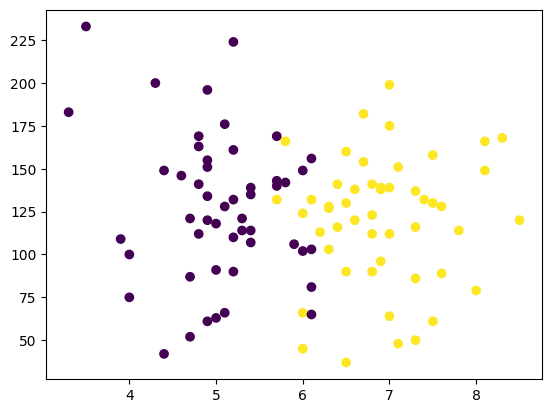

In [54]:
import matplotlib.pyplot as plt

# plt.scatter()
# This is a function from matplotlib.pyplot used to make a scatter plot, which plots points on an X-Y plane.
# df['cgpa']
# This is the X-axis values of your points.
# Each point’s horizontal position corresponds to a student’s cgpa.
# df['iq']
# This is the Y-axis values of your points.
# Each point’s vertical position corresponds to the student’s iq.
# c=df['placement']
# This sets the color of each point based on the placement column.
# Typically:
# 1 → one color (e.g., green for placed)
# 0 → another color (e.g., red for not placed)
# This is a nice way to visually separate placed vs unplaced students in the plot.
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [55]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [56]:
y.shape


(100,)

In [57]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [58]:
X_train

,cgpa,iq
15,5.1,176.0
74,6.7,154.0
21,7.1,151.0
54,6.4,141.0
68,4.0,75.0
...,...,...
30,7.6,128.0
50,3.5,233.0
67,5.0,118.0
84,5.7,169.0


In [59]:
y_train


,placement
15,0
74,1
21,1
54,1
68,0
...,...
30,1
50,0
67,0
84,0


In [60]:
X_test

,cgpa,iq
24,4.7,121.0
39,4.6,146.0
73,4.9,61.0
23,4.7,87.0
55,7.8,114.0
52,7.0,175.0
51,4.8,141.0
41,5.4,114.0
88,4.4,149.0
70,6.3,127.0


In [61]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train = scaler.fit_transform(X_train)


X_train

array([[-0.84400461,  1.29068184],
       [ 0.57747684,  0.7489074 ],
       [ 0.9328472 ,  0.67502907],
       [ 0.31094907,  0.42876796],
       [-1.82127311, -1.19655537],
       [-0.31094907,  0.20713296],
       [-1.11053238,  0.9705424 ],
       [-0.57747684,  0.37951573],
       [ 0.84400461, -0.28538926],
       [ 0.84400461,  1.8570824 ],
       [ 0.75516202,  0.37951573],
       [ 0.22210648,  0.10862851],
       [ 0.84400461, -1.4674426 ],
       [ 0.39979166, -2.13234759],
       [-0.75516202, -0.33464149],
       [ 1.82127311,  0.62577684],
       [ 0.66631943, -0.01450204],
       [-0.0444213 , -1.93533871],
       [ 0.22210648, -0.50702426],
       [ 0.84400461,  0.37951573],
       [-0.84400461, -1.41819037],
       [ 0.9328472 , -1.86146037],
       [ 0.0444213 ,  0.20713296],
       [-1.82127311, -0.5809026 ],
       [-0.22210648,  0.45339407],
       [ 0.75516202,  0.35488962],
       [-1.19937497, -1.76295593],
       [ 0.0444213 , -1.04879871],
       [ 1.37706016,

In [62]:
X_test = scaler.transform(X_test)


X_test

array([[-1.19937497, -0.06375427],
       [-1.28821756,  0.55189851],
       [-1.02168979, -1.54132093],
       [-1.19937497, -0.90104204],
       [ 1.55474534, -0.23613704],
       [ 0.84400461,  1.26605573],
       [-1.11053238,  0.42876796],
       [-0.57747684, -0.23613704],
       [-1.46590275,  0.62577684],
       [ 0.22210648,  0.0840024 ]])

In [63]:
from sklearn.linear_model import LogisticRegression


clf = LogisticRegression()


# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [64]:
y_pred = clf.predict(X_test)


y_test

,placement
24,0
39,0
73,0
23,0
55,1
52,1
51,0
41,0
88,0
70,1


In [65]:
from sklearn.metrics import accuracy_score


accuracy_score(y_test,y_pred)

1.0

<Axes: >

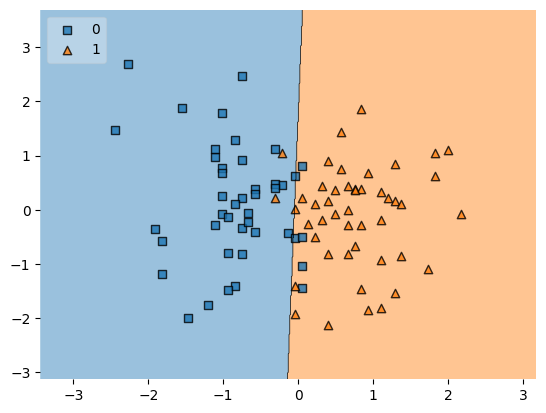

In [66]:
from mlxtend.plotting import plot_decision_regions


plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [67]:
import pickle


pickle.dump(clf,open('model.pkl','wb'))